In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
%matplotlib inline

In [3]:
df = pd.read_csv('/home/revanth/projects/spotify-analysis-ml/data/spotify-tracks-dataset/dataset.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [5]:
df['artists'].value_counts().head(20)

artists
The Beatles              279
George Jones             271
Stevie Wonder            236
Linkin Park              224
Ella Fitzgerald          222
Prateek Kuhad            217
Feid                     202
Chuck Berry              190
Håkan Hellström          183
OneRepublic              181
The Beach Boys           176
my little airport        171
Charlie Brown Jr.        169
Elvis Presley            169
Red Hot Chili Peppers    159
Bryan Adams              157
Scooter                  155
Daddy Yankee             154
Arctic Monkeys           152
BTS                      151
Name: count, dtype: int64

In [13]:
artist_counts = df['artists'].value_counts().head(100)

fig = px.bar(
    x=artist_counts.index,
    y=artist_counts.values,
    labels={'x': 'Artist', 'y': 'Count'},
    title='Top 100 Artists',
    opacity=1
)

fig.show()

In [7]:
popularity = (
    df.groupby('track_name')['popularity']
    .mean()
    .sort_values(ascending=False)
    .head(100)
)

fig = px.bar(
    x=popularity.values,
    y=popularity.index,
    labels={'x': 'Popularity', 'y': 'Track'},
    title='Top 20 Most Popular Tracks'
)

fig.show()

In [8]:
fig = px.scatter(df, x='energy', y='popularity')

fig.show()

# sns.scatterplot(df,x='energy', y='popularity',size_order=1)

In [9]:
fig = px.scatter(df, x='danceability', y='popularity')

fig.show()

In [10]:
corr_matrix = df.corr(numeric_only=True)

fig = px.imshow(
    corr_matrix,
    text_auto=".2f",
    color_continuous_scale="RdBu_r",   # Red-Blue reversed
    range_color=[-1, 1],               # Correlation range
    color_continuous_midpoint=0,       # Center at 0
    title="Correlation Matrix",
    width=800,   # Forces the canvas width to 800 pixels
    height=800
)

# 3. Clean up the label angles so they don't crowd each other
fig.update_xaxes(tickangle=45)

fig.show()

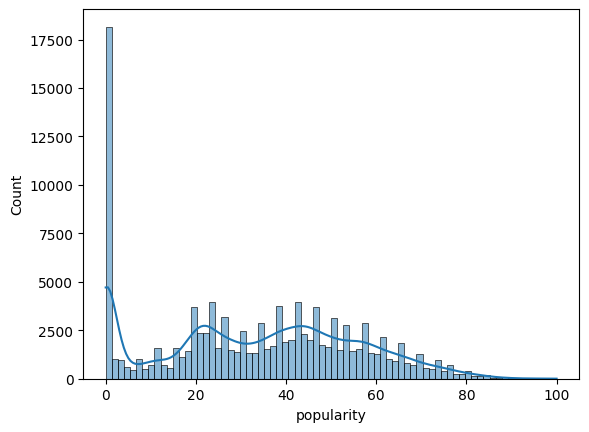

In [11]:
sns.histplot(df['popularity'],kde=True)

plt.show()

In [12]:
df['duration_ms'].describe()

count    1.140000e+05
mean     2.280292e+05
std      1.072977e+05
min      0.000000e+00
25%      1.740660e+05
50%      2.129060e+05
75%      2.615060e+05
max      5.237295e+06
Name: duration_ms, dtype: float64